# TX Housing Market Analysis
## Notebook 03: Market Momentum Model

### Objective

This notebook develops a comparative market-scoring framework for eight North Dallas housing markets using the integrated dataset produced in Notebook 02.

The model separates market strength into three analytical dimensions:

1. **Long-Term Growth Fundamentals**
   - Population growth
   - Historical home-value appreciation
   - Demographic growth acceleration

2. **Current Market Momentum**
   - Current home-value growth
   - Transaction activity
   - Inventory trends
   - Months of supply
   - Sale-to-list ratio

3. **Construction Context**
   - Historical construction intensity
   - Current construction intensity
   - Change from construction peak
   - Single-family share of new residential development

The goal is not to identify a universally "best" market. Instead, the framework distinguishes markets with:

- strong long-term fundamentals,
- strong current market conditions,
- both,
- or neither.

Construction is evaluated separately because high levels of permitting can indicate both strong market expansion and increased future housing supply.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [3]:
# -------------------------------------------------------------------
# PROJECT PATHS
# -------------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

MASTER_FILE = (
    PROCESSED_DATA_DIR
    / "tx_market_master.csv"
)

print("Project root:", PROJECT_ROOT)
print("Master dataset:", MASTER_FILE)
print("File exists:", MASTER_FILE.exists())

Project root: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis
Master dataset: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/processed/tx_market_master.csv
File exists: True


## 1. Load Integrated Market Dataset

The scoring model uses the integrated city-level dataset created in Notebook 02.

Each row represents one target housing market and contains price, demographic, construction, and current market indicators.

In [4]:
# -------------------------------------------------------------------
# LOAD MASTER DATASET
# -------------------------------------------------------------------

market = pd.read_csv(MASTER_FILE)

print("Shape:", market.shape)
print("Cities:", sorted(market["City"].unique()))

market.head()

Shape: (8, 32)
Cities: ['Anna', 'Celina', 'Frisco', 'McKinney', 'Melissa', 'Plano', 'Princeton', 'Prosper']


,City,Latest_ZHVI,Total_Appreciation_Pct,Five_Year_CAGR_Pct,Three_Year_CAGR_Pct,ZHVI_YoY_Pct,Momentum_vs_3yr,ZHVI_From_Peak_Pct,Months_Since_Peak,Latest_Population,Population_Change,Total_Population_Growth_Pct,Population_CAGR_Pct,Latest_Population_YoY_Pct,Population_Growth_Acceleration,Total_Permits_2020_2025,Avg_Annual_Permits,Avg_Permits_Per_1000,Latest_Permits,Latest_Permits_Per_1000,Latest_SF_Share_Pct,Peak_Construction_Year,Peak_Permits_Per_1000,Change_From_Construction_Peak_Pct,Homes_Sold_YoY_Pct,Pending_Sales_YoY_Pct,Inventory_YoY_Pct,New_Listings_YoY_Pct,Months_of_Supply,Median_DOM,DOM_YoY_Change,Sale_to_List_Pct
0,Anna,"345,077.93",31.91,1.01,-4.62,-7.08,-2.46,-20.84,48,"35,245.00","17,629.00",100.07,14.88,10.15,-4.37,6970,"1,161.67",46.91,864,24.51,100.00,2022,60.69,-59.61,4.48,5.88,10.74,-1.88,5.90,76.00,14.00,97.73
1,Celina,"522,656.82",45.35,2.85,-3.60,-9.34,-5.73,-17.01,48,"64,427.00","46,394.00",257.27,29.00,24.58,6.55,18534,"3,089.00",89.64,2803,43.51,88.80,2021,143.13,-69.60,34.45,44.17,15.93,23.48,6.80,83.00,10.00,96.50
2,Frisco,"649,172.68",50.67,3.81,-1.87,-4.56,-2.69,-9.64,48,"236,955.00","34,206.00",16.87,3.17,0.76,-2.89,19850,"3,308.33",14.90,5652,23.85,19.29,2025,23.85,0.00,6.57,-1.81,4.70,-0.18,4.90,50.00,2.00,97.29
3,McKinney,"480,264.85",42.73,2.67,-3.23,-6.11,-2.89,-13.80,48,"236,001.00","38,494.00",19.49,3.63,3.74,-1.67,19096,"3,182.67",14.72,3040,12.88,54.24,2023,22.25,-42.10,-5.24,-12.53,-10.07,-14.55,4.10,45.00,0.00,97.76
4,Melissa,"430,393.87",40.56,2.10,-3.63,-6.02,-2.39,-17.95,48,"29,969.00","15,630.00",109.00,15.89,14.48,4.49,5765,960.83,47.25,553,18.45,100.00,2022,75.89,-75.69,-4.55,-16.67,-13.59,-12.64,5.20,60.00,3.00,97.90


In [5]:
# -------------------------------------------------------------------
# VALIDATE MODEL INPUT
# -------------------------------------------------------------------

print("Rows:", len(market))
print("Columns:", len(market.columns))
print("Unique cities:", market["City"].nunique())
print("Duplicate cities:", market["City"].duplicated().sum())
print("Missing values:", market.isna().sum().sum())

Rows: 8
Columns: 32
Unique cities: 8
Duplicate cities: 0
Missing values: 0


## 2. Define Model Indicators

The variable-selection process in Notebook 02 identified a reduced set of indicators designed to limit redundancy while preserving distinct economic dimensions.

### Long-Term Fundamentals

Higher values are interpreted as stronger:

- Population CAGR
- Five-year ZHVI CAGR
- Population growth acceleration

### Current Market Momentum

Higher values are stronger for:

- Year-over-year ZHVI growth
- Year-over-year home-sales growth
- Sale-to-list ratio

Lower values are stronger for:

- Year-over-year inventory growth
- Months of supply

### Construction Context

Construction variables are retained separately and are not automatically interpreted as uniformly positive or negative.

In [6]:
# -------------------------------------------------------------------
# MODEL VARIABLES
# -------------------------------------------------------------------

fundamentals_variables = [
    "Population_CAGR_Pct",
    "Five_Year_CAGR_Pct",
    "Population_Growth_Acceleration"
]

momentum_positive_variables = [
    "ZHVI_YoY_Pct",
    "Homes_Sold_YoY_Pct",
    "Sale_to_List_Pct"
]

momentum_negative_variables = [
    "Inventory_YoY_Pct",
    "Months_of_Supply"
]

construction_context_variables = [
    "Avg_Permits_Per_1000",
    "Latest_Permits_Per_1000",
    "Change_From_Construction_Peak_Pct",
    "Latest_SF_Share_Pct"
]

print("Long-Term Fundamentals:")
for var in fundamentals_variables:
    print("-", var)

print("\nCurrent Momentum — Higher is Better:")
for var in momentum_positive_variables:
    print("-", var)

print("\nCurrent Momentum — Lower is Better:")
for var in momentum_negative_variables:
    print("-", var)

Long-Term Fundamentals:
- Population_CAGR_Pct
- Five_Year_CAGR_Pct
- Population_Growth_Acceleration

Current Momentum — Higher is Better:
- ZHVI_YoY_Pct
- Homes_Sold_YoY_Pct
- Sale_to_List_Pct

Current Momentum — Lower is Better:
- Inventory_YoY_Pct
- Months_of_Supply


In [7]:
# -------------------------------------------------------------------
# MODEL INPUT TABLE
# -------------------------------------------------------------------

model_columns = (
    ["City"]
    + fundamentals_variables
    + momentum_positive_variables
    + momentum_negative_variables
    + construction_context_variables
)

model_data = market[
    model_columns
].copy()

model_data.round(2)

,City,Population_CAGR_Pct,Five_Year_CAGR_Pct,Population_Growth_Acceleration,ZHVI_YoY_Pct,Homes_Sold_YoY_Pct,Sale_to_List_Pct,Inventory_YoY_Pct,Months_of_Supply,Avg_Permits_Per_1000,Latest_Permits_Per_1000,Change_From_Construction_Peak_Pct,Latest_SF_Share_Pct
0,Anna,14.88,1.01,-4.37,-7.08,4.48,97.73,10.74,5.90,46.91,24.51,-59.61,100.00
1,Celina,29.00,2.85,6.55,-9.34,34.45,96.50,15.93,6.80,89.64,43.51,-69.60,88.80
2,Frisco,3.17,3.81,-2.89,-4.56,6.57,97.29,4.70,4.90,14.90,23.85,0.00,19.29
3,McKinney,3.63,2.67,-1.67,-6.11,-5.24,97.76,-10.07,4.10,14.72,12.88,-42.10,54.24
4,Melissa,15.89,2.10,4.49,-6.02,-4.55,97.90,-13.59,5.20,47.25,18.45,-75.69,100.00
5,Plano,0.46,3.23,-0.13,-4.43,4.27,97.90,-19.70,3.40,2.88,1.07,-82.50,44.09
6,Princeton,19.99,-0.35,-12.45,-10.23,40.06,97.33,-1.06,3.30,61.87,36.99,-63.76,99.25
7,Prosper,8.15,3.96,-3.45,-5.71,-6.18,96.36,0.24,5.30,24.66,5.72,-85.29,100.00


## 3. Normalize Indicators

Model indicators are normalized to a 0–100 relative scale using min-max normalization.

For indicators where higher values represent stronger conditions:

**0 = weakest observed market**

**100 = strongest observed market**

For indicators where lower values represent stronger conditions, the normalized scale is reversed.

Because only eight markets are included, these scores are relative to the comparison group and should not be interpreted as absolute benchmarks for the broader U.S. housing market.

In [8]:
# -------------------------------------------------------------------
# NORMALIZATION FUNCTIONS
# -------------------------------------------------------------------

def minmax_score(series):
    """
    Higher raw values receive higher 0-100 scores.
    """
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            50.0,
            index=series.index
        )

    return (
        (series - minimum)
        / (maximum - minimum)
        * 100
    )


def reverse_minmax_score(series):
    """
    Lower raw values receive higher 0-100 scores.
    """
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            50.0,
            index=series.index
        )

    return (
        (maximum - series)
        / (maximum - minimum)
        * 100
    )

In [9]:
# -------------------------------------------------------------------
# NORMALIZE LONG-TERM FUNDAMENTALS
# -------------------------------------------------------------------

scores = market[["City"]].copy()

for var in fundamentals_variables:
    scores[f"{var}_Score"] = minmax_score(
        market[var]
    )

scores[
    ["City"]
    + [
        f"{var}_Score"
        for var in fundamentals_variables
    ]
].round(2)

,City,Population_CAGR_Pct_Score,Five_Year_CAGR_Pct_Score,Population_Growth_Acceleration_Score
0,Anna,50.52,31.61,42.50
1,Celina,100.00,74.33,100.00
2,Frisco,9.49,96.50,50.31
3,McKinney,11.10,70.21,56.74
4,Melissa,54.05,56.94,89.13
5,Plano,0.00,83.04,64.84
6,Princeton,68.41,0.00,0.00
7,Prosper,26.93,100.00,47.37


In [10]:
# -------------------------------------------------------------------
# NORMALIZE CURRENT MARKET MOMENTUM
# -------------------------------------------------------------------

for var in momentum_positive_variables:
    scores[f"{var}_Score"] = minmax_score(
        market[var]
    )

for var in momentum_negative_variables:
    scores[f"{var}_Score"] = reverse_minmax_score(
        market[var]
    )

In [11]:
momentum_score_columns = [
    f"{var}_Score"
    for var in (
        momentum_positive_variables
        + momentum_negative_variables
    )
]

scores[
    ["City"] + momentum_score_columns
].round(2)

,City,ZHVI_YoY_Pct_Score,Homes_Sold_YoY_Pct_Score,Sale_to_List_Pct_Score,Inventory_YoY_Pct_Score,Months_of_Supply_Score
0,Anna,54.24,23.04,88.96,14.55,25.71
1,Celina,15.34,87.86,9.09,0.00,0.00
2,Frisco,97.72,27.57,60.39,31.50,54.29
3,McKinney,70.92,2.03,90.91,72.96,77.14
4,Melissa,72.48,3.53,100.00,82.85,45.71
5,Plano,100.00,22.60,100.00,100.00,97.14
6,Princeton,0.00,100.00,62.99,47.67,100.00
7,Prosper,77.96,0.00,0.00,44.03,42.86


In [12]:
# -------------------------------------------------------------------
# VERIFY NORMALIZED SCORE RANGES
# -------------------------------------------------------------------

score_columns = [
    col
    for col in scores.columns
    if col.endswith("_Score")
]

normalization_check = pd.DataFrame({
    "Min_Score": scores[score_columns].min(),
    "Max_Score": scores[score_columns].max()
})

normalization_check.round(2)

,Min_Score,Max_Score
Population_CAGR_Pct_Score,0.00,100.00
Five_Year_CAGR_Pct_Score,0.00,100.00
Population_Growth_Acceleration_Score,0.00,100.00
ZHVI_YoY_Pct_Score,0.00,100.00
Homes_Sold_YoY_Pct_Score,0.00,100.00
Sale_to_List_Pct_Score,0.00,100.00
Inventory_YoY_Pct_Score,0.00,100.00
Months_of_Supply_Score,0.00,100.00


In [13]:
fundamentals_score_columns = [
    f"{var}_Score"
    for var in fundamentals_variables
]

fundamentals_normalized = scores[
    ["City"] + fundamentals_score_columns
].copy()

fundamentals_normalized.round(2)

,City,Population_CAGR_Pct_Score,Five_Year_CAGR_Pct_Score,Population_Growth_Acceleration_Score
0,Anna,50.52,31.61,42.50
1,Celina,100.00,74.33,100.00
2,Frisco,9.49,96.50,50.31
3,McKinney,11.10,70.21,56.74
4,Melissa,54.05,56.94,89.13
5,Plano,0.00,83.04,64.84
6,Princeton,68.41,0.00,0.00
7,Prosper,26.93,100.00,47.37


In [14]:
momentum_normalized = scores[
    ["City"] + momentum_score_columns
].copy()

momentum_normalized.round(2)

,City,ZHVI_YoY_Pct_Score,Homes_Sold_YoY_Pct_Score,Sale_to_List_Pct_Score,Inventory_YoY_Pct_Score,Months_of_Supply_Score
0,Anna,54.24,23.04,88.96,14.55,25.71
1,Celina,15.34,87.86,9.09,0.00,0.00
2,Frisco,97.72,27.57,60.39,31.50,54.29
3,McKinney,70.92,2.03,90.91,72.96,77.14
4,Melissa,72.48,3.53,100.00,82.85,45.71
5,Plano,100.00,22.60,100.00,100.00,97.14
6,Princeton,0.00,100.00,62.99,47.67,100.00
7,Prosper,77.96,0.00,0.00,44.03,42.86


## 4. Composite Score Weighting

After normalization, the indicators are combined into two composite scores: a Long-Term Fundamentals Score and a Current Market Momentum Score.

Weights are assigned by economic dimension rather than solely by statistical relationships. The objective is to prevent any single indicator from dominating the model while giving greater importance to measures most directly connected to long-term housing demand and current market balance.

### Long-Term Fundamentals

- **Population CAGR — 45%**
  - Represents sustained expansion in the underlying resident base and long-term housing demand.
- **Five-Year ZHVI CAGR — 35%**
  - Represents realized medium-term home-value appreciation.
- **Population Growth Acceleration — 20%**
  - Captures whether demographic growth is strengthening or weakening relative to its recent history.

### Current Market Momentum

- **ZHVI YoY Growth — 25%**
  - Measures current home-value direction.
- **Homes Sold YoY Growth — 20%**
  - Measures transaction momentum.
- **Inventory YoY Growth — 20%**
  - Measures whether available housing supply is expanding or contracting.
- **Months of Supply — 20%**
  - Measures the current balance between supply and demand.
- **Sale-to-List Ratio — 15%**
  - Measures seller pricing power.

For inventory growth and months of supply, lower raw values receive higher normalized scores.

The weighting structure is treated as a baseline specification rather than an objectively correct set of parameters. Alternative weighting scenarios are tested later to determine whether market rankings are robust to reasonable changes in model assumptions.

In [15]:
# -------------------------------------------------------------------
# BASELINE MODEL WEIGHTS
# -------------------------------------------------------------------

fundamentals_weights = {
    "Population_CAGR_Pct_Score": 0.45,
    "Five_Year_CAGR_Pct_Score": 0.35,
    "Population_Growth_Acceleration_Score": 0.20
}

momentum_weights = {
    "ZHVI_YoY_Pct_Score": 0.25,
    "Homes_Sold_YoY_Pct_Score": 0.20,
    "Inventory_YoY_Pct_Score": 0.20,
    "Months_of_Supply_Score": 0.20,
    "Sale_to_List_Pct_Score": 0.15
}

print(
    "Fundamentals weight total:",
    sum(fundamentals_weights.values())
)

print(
    "Momentum weight total:",
    sum(momentum_weights.values())
)

Fundamentals weight total: 1.0
Momentum weight total: 1.0


In [16]:
# -------------------------------------------------------------------
# LONG-TERM FUNDAMENTALS SCORE
# -------------------------------------------------------------------

scores["Long_Term_Fundamentals_Score"] = sum(
    scores[column] * weight
    for column, weight
    in fundamentals_weights.items()
)

fundamentals_results = scores[
    [
        "City",
        "Population_CAGR_Pct_Score",
        "Five_Year_CAGR_Pct_Score",
        "Population_Growth_Acceleration_Score",
        "Long_Term_Fundamentals_Score"
    ]
].sort_values(
    "Long_Term_Fundamentals_Score",
    ascending=False
)

fundamentals_results.round(2)

,City,Population_CAGR_Pct_Score,Five_Year_CAGR_Pct_Score,Population_Growth_Acceleration_Score,Long_Term_Fundamentals_Score
1,Celina,100.00,74.33,100.00,91.02
4,Melissa,54.05,56.94,89.13,62.08
7,Prosper,26.93,100.00,47.37,56.59
2,Frisco,9.49,96.50,50.31,48.11
0,Anna,50.52,31.61,42.50,42.30
5,Plano,0.00,83.04,64.84,42.03
3,McKinney,11.10,70.21,56.74,40.91
6,Princeton,68.41,0.00,0.00,30.79


In [17]:
# -------------------------------------------------------------------
# CURRENT MARKET MOMENTUM SCORE
# -------------------------------------------------------------------

scores["Current_Market_Momentum_Score"] = sum(
    scores[column] * weight
    for column, weight
    in momentum_weights.items()
)

momentum_results = scores[
    [
        "City",
        "ZHVI_YoY_Pct_Score",
        "Homes_Sold_YoY_Pct_Score",
        "Inventory_YoY_Pct_Score",
        "Months_of_Supply_Score",
        "Sale_to_List_Pct_Score",
        "Current_Market_Momentum_Score"
    ]
].sort_values(
    "Current_Market_Momentum_Score",
    ascending=False
)

momentum_results.round(2)

,City,ZHVI_YoY_Pct_Score,Homes_Sold_YoY_Pct_Score,Inventory_YoY_Pct_Score,Months_of_Supply_Score,Sale_to_List_Pct_Score,Current_Market_Momentum_Score
5,Plano,100.00,22.60,100.00,97.14,100.00,83.95
3,McKinney,70.92,2.03,72.96,77.14,90.91,61.79
4,Melissa,72.48,3.53,82.85,45.71,100.00,59.54
6,Princeton,0.00,100.00,47.67,100.00,62.99,58.98
2,Frisco,97.72,27.57,31.50,54.29,60.39,56.16
0,Anna,54.24,23.04,14.55,25.71,88.96,39.57
7,Prosper,77.96,0.00,44.03,42.86,0.00,36.87
1,Celina,15.34,87.86,0.00,0.00,9.09,22.77


In [18]:
# -------------------------------------------------------------------
# ADD FUNDAMENTALS AND MOMENTUM RANKS
# -------------------------------------------------------------------

scores["Fundamentals_Rank"] = (
    scores["Long_Term_Fundamentals_Score"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

scores["Momentum_Rank"] = (
    scores["Current_Market_Momentum_Score"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

ranking_summary = scores[
    [
        "City",
        "Long_Term_Fundamentals_Score",
        "Fundamentals_Rank",
        "Current_Market_Momentum_Score",
        "Momentum_Rank"
    ]
].sort_values(
    "Fundamentals_Rank"
)

ranking_summary.round(2)

,City,Long_Term_Fundamentals_Score,Fundamentals_Rank,Current_Market_Momentum_Score,Momentum_Rank
1,Celina,91.02,1,22.77,8
4,Melissa,62.08,2,59.54,3
7,Prosper,56.59,3,36.87,7
2,Frisco,48.11,4,56.16,5
0,Anna,42.30,5,39.57,6
5,Plano,42.03,6,83.95,1
3,McKinney,40.91,7,61.79,2
6,Princeton,30.79,8,58.98,4


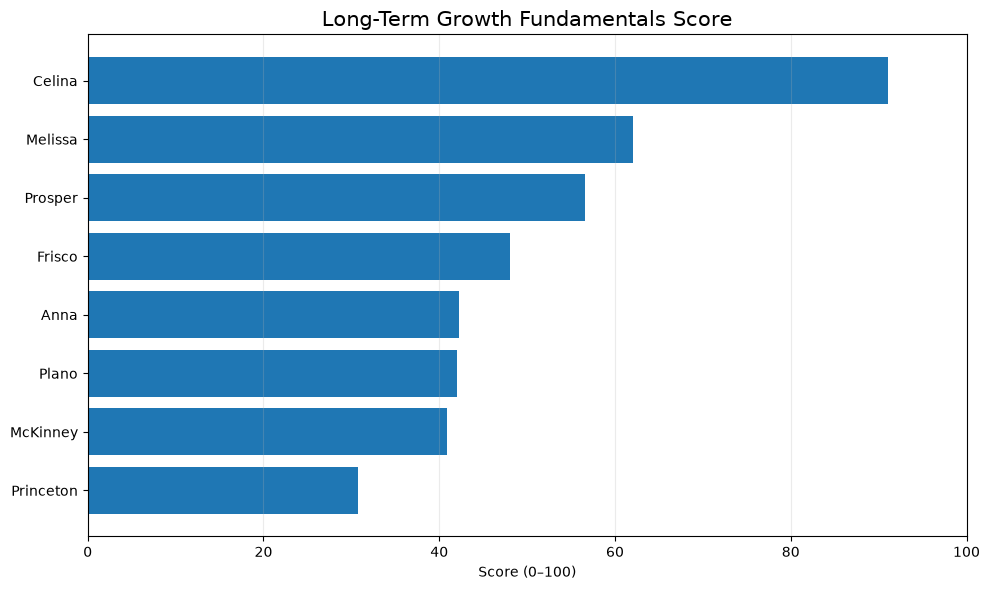

In [19]:
# -------------------------------------------------------------------
# LONG-TERM FUNDAMENTALS RANKING
# -------------------------------------------------------------------

plot_data = ranking_summary.sort_values(
    "Long_Term_Fundamentals_Score"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_data["City"],
    plot_data["Long_Term_Fundamentals_Score"]
)

ax.set_title(
    "Long-Term Growth Fundamentals Score",
    fontsize=15
)

ax.set_xlabel("Score (0–100)")
ax.set_ylabel("")

ax.set_xlim(0, 100)

ax.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()

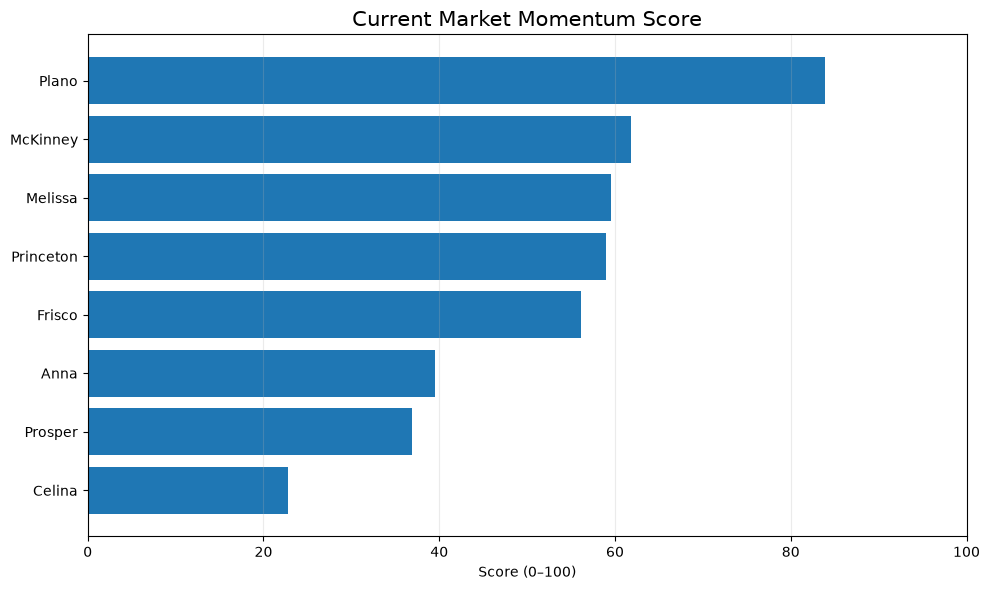

In [20]:
# -------------------------------------------------------------------
# CURRENT MARKET MOMENTUM RANKING
# -------------------------------------------------------------------

plot_data = ranking_summary.sort_values(
    "Current_Market_Momentum_Score"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_data["City"],
    plot_data["Current_Market_Momentum_Score"]
)

ax.set_title(
    "Current Market Momentum Score",
    fontsize=15
)

ax.set_xlabel("Score (0–100)")
ax.set_ylabel("")

ax.set_xlim(0, 100)

ax.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()

## 5. Fundamentals vs. Current Momentum

A two-dimensional framework provides a more informative comparison than a single ranking because long-term structural strength and current market conditions can diverge.

Markets in the upper-right portion of the chart combine stronger long-term fundamentals with stronger current momentum.

Markets in the upper-left exhibit stronger long-term fundamentals but weaker current conditions.

Markets in the lower-right exhibit weaker structural growth but comparatively stronger current conditions.

Markets in the lower-left score below the comparison-group averages on both dimensions.

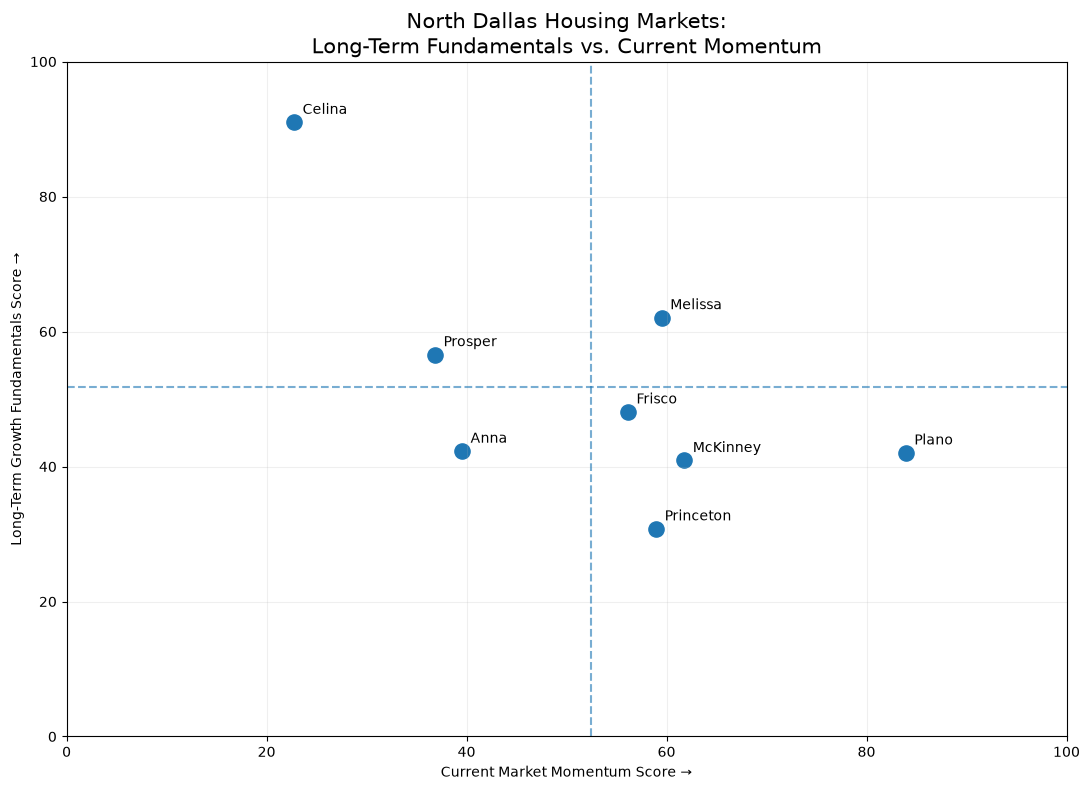

In [21]:
# -------------------------------------------------------------------
# FUNDAMENTALS VS CURRENT MOMENTUM
# -------------------------------------------------------------------

x = scores["Current_Market_Momentum_Score"]
y = scores["Long_Term_Fundamentals_Score"]

x_mid = x.mean()
y_mid = y.mean()

fig, ax = plt.subplots(figsize=(11, 8))

ax.scatter(
    x,
    y,
    s=120
)

for _, row in scores.iterrows():
    ax.annotate(
        row["City"],
        (
            row["Current_Market_Momentum_Score"],
            row["Long_Term_Fundamentals_Score"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

ax.axvline(
    x_mid,
    linestyle="--",
    alpha=0.6
)

ax.axhline(
    y_mid,
    linestyle="--",
    alpha=0.6
)

ax.set_title(
    "North Dallas Housing Markets:\n"
    "Long-Term Fundamentals vs. Current Momentum",
    fontsize=15
)

ax.set_xlabel(
    "Current Market Momentum Score →"
)

ax.set_ylabel(
    "Long-Term Growth Fundamentals Score →"
)

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

ax.grid(alpha=0.20)

plt.tight_layout()
plt.show()

In [22]:
# -------------------------------------------------------------------
# MARKET PROFILE CLASSIFICATION
# -------------------------------------------------------------------

def classify_market(row):

    strong_fundamentals = (
        row["Long_Term_Fundamentals_Score"]
        >= y_mid
    )

    strong_momentum = (
        row["Current_Market_Momentum_Score"]
        >= x_mid
    )

    if strong_fundamentals and strong_momentum:
        return "Strong Fundamentals + Strong Momentum"

    elif strong_fundamentals and not strong_momentum:
        return "Strong Fundamentals + Weak Momentum"

    elif not strong_fundamentals and strong_momentum:
        return "Weaker Fundamentals + Strong Momentum"

    else:
        return "Weaker Fundamentals + Weak Momentum"


scores["Market_Profile"] = scores.apply(
    classify_market,
    axis=1
)

market_profiles = scores[
    [
        "City",
        "Long_Term_Fundamentals_Score",
        "Current_Market_Momentum_Score",
        "Market_Profile"
    ]
].sort_values(
    [
        "Long_Term_Fundamentals_Score",
        "Current_Market_Momentum_Score"
    ],
    ascending=False
)

market_profiles.round(2)

,City,Long_Term_Fundamentals_Score,Current_Market_Momentum_Score,Market_Profile
1,Celina,91.02,22.77,Strong Fundamentals + Weak Momentum
4,Melissa,62.08,59.54,Strong Fundamentals + Strong Momentum
7,Prosper,56.59,36.87,Strong Fundamentals + Weak Momentum
2,Frisco,48.11,56.16,Weaker Fundamentals + Strong Momentum
0,Anna,42.30,39.57,Weaker Fundamentals + Weak Momentum
5,Plano,42.03,83.95,Weaker Fundamentals + Strong Momentum
3,McKinney,40.91,61.79,Weaker Fundamentals + Strong Momentum
6,Princeton,30.79,58.98,Weaker Fundamentals + Strong Momentum


### Baseline Model Results

The baseline scoring model reveals a substantial divergence between long-term structural growth and current housing-market conditions.

**Celina ranks first in Long-Term Fundamentals (91.02) but last in Current Market Momentum (22.77).** Its exceptional demographic expansion drives its fundamentals score, while current conditions are weakened by declining home values, rapidly expanding inventory, elevated months of supply, and weaker seller pricing power. Strong transaction growth prevents the current picture from being uniformly negative, but the market currently appears to be absorbing substantial new supply.

**Melissa provides the strongest balance between the two dimensions**, ranking second in fundamentals (62.08) and third in momentum (59.54). Its demographic growth remains strong while current inventory conditions and seller pricing power compare favorably with many of the other growth markets.

**Prosper ranks third in fundamentals but seventh in momentum.** Its strong historical appreciation supports its structural score, while weaker transaction activity and current market competitiveness reduce its momentum score.

**Plano represents the opposite profile from Celina.** It ranks only sixth in fundamentals (42.03), reflecting its mature and nearly flat population base, but ranks first in current momentum (83.95). Relative price resilience, contracting inventory, low months of supply, and strong seller pricing power make Plano the strongest current market in the comparison.

**McKinney also exhibits stronger current conditions than long-term growth**, ranking seventh in fundamentals but second in momentum.

**Princeton presents a mixed recovery profile.** Despite ranking last in fundamentals under the baseline specification—primarily because of weak five-year appreciation and recent demographic deceleration—it ranks fourth in current momentum. Its very strong transaction growth and low months of supply offset its substantial current price decline.

Overall, the results demonstrate why structural fundamentals and current momentum should not be treated as interchangeable measures of investment attractiveness.

## 6. Investor Preference Scenarios

Long-term fundamentals and current market momentum capture different investment considerations. Combining them requires an explicit assumption about investor priorities.

Rather than assuming that one weighting scheme is universally correct, three investor scenarios are evaluated:

- **Growth-Oriented:** 70% Long-Term Fundamentals / 30% Current Momentum
- **Balanced:** 50% Long-Term Fundamentals / 50% Current Momentum
- **Momentum-Oriented:** 30% Long-Term Fundamentals / 70% Current Momentum

Comparing rankings across these scenarios helps determine whether a market's attractiveness is robust or dependent on a particular investment philosophy.

In [24]:
# -------------------------------------------------------------------
# INVESTOR PREFERENCE SCENARIOS
# -------------------------------------------------------------------

scores["Growth_Oriented_Score"] = (
    0.70 * scores["Long_Term_Fundamentals_Score"]
    + 0.30 * scores["Current_Market_Momentum_Score"]
)

scores["Balanced_Score"] = (
    0.50 * scores["Long_Term_Fundamentals_Score"]
    + 0.50 * scores["Current_Market_Momentum_Score"]
)

scores["Momentum_Oriented_Score"] = (
    0.30 * scores["Long_Term_Fundamentals_Score"]
    + 0.70 * scores["Current_Market_Momentum_Score"]
)

In [25]:
# -------------------------------------------------------------------
# SCENARIO RANKINGS
# -------------------------------------------------------------------

scenario_scores = [
    "Growth_Oriented_Score",
    "Balanced_Score",
    "Momentum_Oriented_Score"
]

for column in scenario_scores:

    rank_column = column.replace(
        "_Score",
        "_Rank"
    )

    scores[rank_column] = (
        scores[column]
        .rank(
            ascending=False,
            method="min"
        )
        .astype(int)
    )

In [26]:
scenario_results = scores[
    [
        "City",

        "Long_Term_Fundamentals_Score",
        "Current_Market_Momentum_Score",

        "Growth_Oriented_Score",
        "Growth_Oriented_Rank",

        "Balanced_Score",
        "Balanced_Rank",

        "Momentum_Oriented_Score",
        "Momentum_Oriented_Rank"
    ]
].sort_values(
    "Balanced_Rank"
)

scenario_results.round(2)

,City,Long_Term_Fundamentals_Score,Current_Market_Momentum_Score,Growth_Oriented_Score,Growth_Oriented_Rank,Balanced_Score,Balanced_Rank,Momentum_Oriented_Score,Momentum_Oriented_Rank
5,Plano,42.03,83.95,54.61,3,62.99,1,71.37,1
4,Melissa,62.08,59.54,61.32,2,60.81,2,60.30,2
1,Celina,91.02,22.77,70.54,1,56.89,3,43.24,6
2,Frisco,48.11,56.16,50.52,5,52.13,4,53.74,4
3,McKinney,40.91,61.79,47.18,6,51.35,5,55.53,3
7,Prosper,56.59,36.87,50.68,4,46.73,6,42.79,7
6,Princeton,30.79,58.98,39.25,8,44.88,7,50.52,5
0,Anna,42.30,39.57,41.48,7,40.93,8,40.38,8


In [27]:
# -------------------------------------------------------------------
# RANKING STABILITY
# -------------------------------------------------------------------

rank_columns = [
    "Growth_Oriented_Rank",
    "Balanced_Rank",
    "Momentum_Oriented_Rank"
]

scores["Best_Scenario_Rank"] = (
    scores[rank_columns].min(axis=1)
)

scores["Worst_Scenario_Rank"] = (
    scores[rank_columns].max(axis=1)
)

scores["Rank_Range"] = (
    scores["Worst_Scenario_Rank"]
    - scores["Best_Scenario_Rank"]
)

ranking_stability = scores[
    [
        "City",
        "Growth_Oriented_Rank",
        "Balanced_Rank",
        "Momentum_Oriented_Rank",
        "Best_Scenario_Rank",
        "Worst_Scenario_Rank",
        "Rank_Range"
    ]
].sort_values(
    [
        "Rank_Range",
        "Balanced_Rank"
    ]
)

ranking_stability

,City,Growth_Oriented_Rank,Balanced_Rank,Momentum_Oriented_Rank,Best_Scenario_Rank,Worst_Scenario_Rank,Rank_Range
4,Melissa,2,2,2,2,2,0
2,Frisco,5,4,4,4,5,1
0,Anna,7,8,8,7,8,1
5,Plano,3,1,1,1,3,2
3,McKinney,6,5,3,3,6,3
7,Prosper,4,6,7,4,7,3
6,Princeton,8,7,5,5,8,3
1,Celina,1,3,6,1,6,5


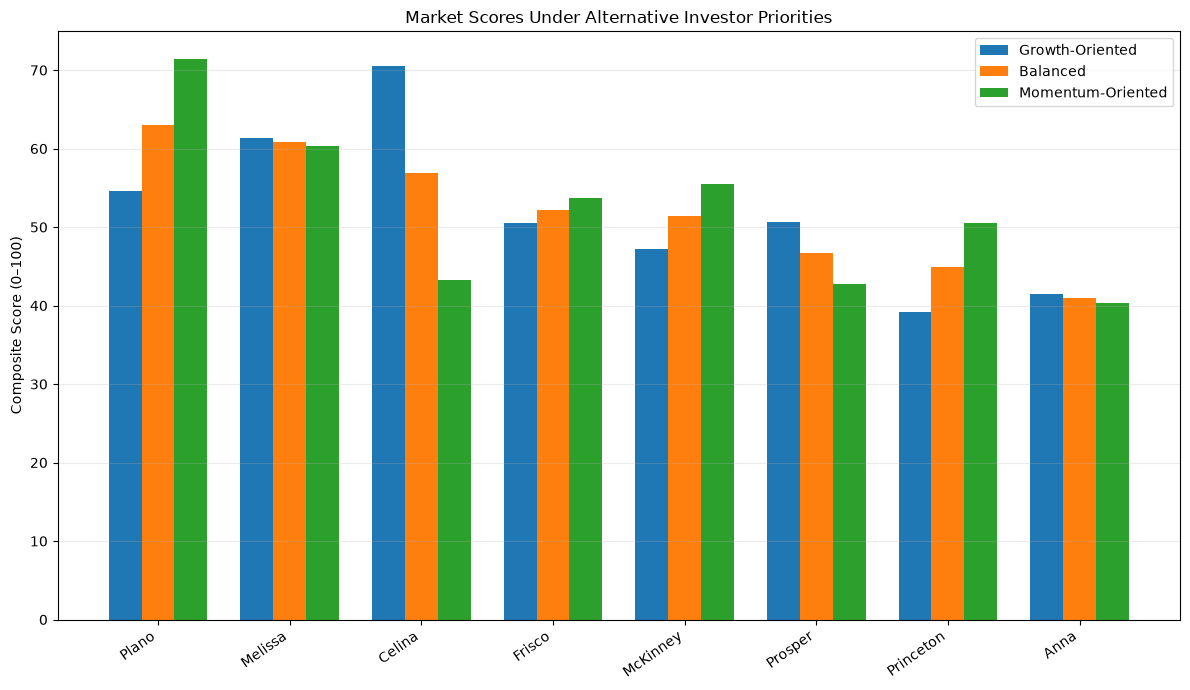

In [28]:
# -------------------------------------------------------------------
# INVESTOR SCENARIO SCORE COMPARISON
# -------------------------------------------------------------------

scenario_plot = scores[
    [
        "City",
        "Growth_Oriented_Score",
        "Balanced_Score",
        "Momentum_Oriented_Score"
    ]
].copy()

scenario_plot = scenario_plot.sort_values(
    "Balanced_Score",
    ascending=False
)

x = np.arange(len(scenario_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 7))

ax.bar(
    x - width,
    scenario_plot["Growth_Oriented_Score"],
    width,
    label="Growth-Oriented"
)

ax.bar(
    x,
    scenario_plot["Balanced_Score"],
    width,
    label="Balanced"
)

ax.bar(
    x + width,
    scenario_plot["Momentum_Oriented_Score"],
    width,
    label="Momentum-Oriented"
)

ax.set_xticks(x)

ax.set_xticklabels(
    scenario_plot["City"],
    rotation=35,
    ha="right"
)

ax.set_ylabel("Composite Score (0–100)")

ax.set_title(
    "Market Scores Under Alternative Investor Priorities"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

## 7. Monte Carlo Weight Sensitivity Analysis

Composite market rankings depend partly on the weights assigned to individual indicators. Rather than relying only on the baseline weighting assumptions, a Monte Carlo sensitivity analysis is used to evaluate ranking robustness.

Each simulation randomly generates a valid set of weights for:

- the three Long-Term Fundamentals indicators,
- the five Current Market Momentum indicators, and
- the relative importance of Fundamentals versus Momentum.

The resulting composite market scores and rankings are recalculated thousands of times.

This analysis measures:

- probability of ranking #1,
- probability of ranking in the top three,
- average rank,
- median rank,
- best observed rank,
- worst observed rank.

Markets that remain highly ranked across many alternative weighting specifications can be interpreted as more robust to model assumptions. Markets whose rankings vary substantially are more dependent on investor priorities and weighting choices.

The simulation evaluates sensitivity to model weights only. It does not represent uncertainty in future housing-market outcomes.

In [29]:
# -------------------------------------------------------------------
# MONTE CARLO WEIGHT SENSITIVITY SETUP
# -------------------------------------------------------------------

N_SIMULATIONS = 10_000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

fundamental_score_cols = [
    "Population_CAGR_Pct_Score",
    "Five_Year_CAGR_Pct_Score",
    "Population_Growth_Acceleration_Score"
]

momentum_score_cols = [
    "ZHVI_YoY_Pct_Score",
    "Homes_Sold_YoY_Pct_Score",
    "Inventory_YoY_Pct_Score",
    "Months_of_Supply_Score",
    "Sale_to_List_Pct_Score"
]

print("Simulations:", N_SIMULATIONS)
print("Fundamental indicators:", len(fundamental_score_cols))
print("Momentum indicators:", len(momentum_score_cols))

Simulations: 10000
Fundamental indicators: 3
Momentum indicators: 5


In [30]:
# -------------------------------------------------------------------
# GENERATE RANDOM WITHIN-SCORE WEIGHTS
# -------------------------------------------------------------------

fundamental_weight_draws = rng.dirichlet(
    np.ones(len(fundamental_score_cols)),
    size=N_SIMULATIONS
)

momentum_weight_draws = rng.dirichlet(
    np.ones(len(momentum_score_cols)),
    size=N_SIMULATIONS
)

print(
    "Fundamental weight matrix:",
    fundamental_weight_draws.shape
)

print(
    "Momentum weight matrix:",
    momentum_weight_draws.shape
)

print(
    "\nExample fundamental weights:",
    fundamental_weight_draws[0].round(3)
)

print(
    "Sum:",
    fundamental_weight_draws[0].sum().round(3)
)

Fundamental weight matrix: (10000, 3)
Momentum weight matrix: (10000, 5)

Example fundamental weights: [0.337 0.328 0.335]
Sum: 1.0


In [31]:
# -------------------------------------------------------------------
# GENERATE FUNDAMENTALS VS MOMENTUM WEIGHTS
# -------------------------------------------------------------------

fundamentals_share = rng.uniform(
    0.30,
    0.70,
    size=N_SIMULATIONS
)

momentum_share = 1 - fundamentals_share

print(
    "Fundamentals share range:",
    fundamentals_share.min().round(3),
    "to",
    fundamentals_share.max().round(3)
)

print(
    "Average fundamentals share:",
    fundamentals_share.mean().round(3)
)

Fundamentals share range: 0.3 to 0.7
Average fundamentals share: 0.499


In [32]:
# -------------------------------------------------------------------
# PREPARE SCORE MATRICES
# -------------------------------------------------------------------

fundamental_matrix = scores[
    fundamental_score_cols
].to_numpy()

momentum_matrix = scores[
    momentum_score_cols
].to_numpy()

cities = scores["City"].to_numpy()

print("Fundamental matrix:", fundamental_matrix.shape)
print("Momentum matrix:", momentum_matrix.shape)
print("Cities:", cities)

Fundamental matrix: (8, 3)
Momentum matrix: (8, 5)
Cities: ['Anna' 'Celina' 'Frisco' 'McKinney' 'Melissa' 'Plano' 'Princeton'
 'Prosper']


In [33]:
# -------------------------------------------------------------------
# SIMULATE FUNDAMENTALS AND MOMENTUM SCORES
# -------------------------------------------------------------------

simulated_fundamentals = (
    fundamental_matrix
    @ fundamental_weight_draws.T
)

simulated_momentum = (
    momentum_matrix
    @ momentum_weight_draws.T
)

simulated_overall = (
    simulated_fundamentals
    * fundamentals_share
    +
    simulated_momentum
    * momentum_share
)

print(
    "Simulated overall score matrix:",
    simulated_overall.shape
)

Simulated overall score matrix: (8, 10000)


In [34]:
# -------------------------------------------------------------------
# CALCULATE RANKS FOR EVERY SIMULATION
# -------------------------------------------------------------------

order = np.argsort(
    -simulated_overall,
    axis=0
)

simulated_ranks = np.empty_like(
    order,
    dtype=int
)

simulation_numbers = np.arange(
    N_SIMULATIONS
)

for rank_position in range(len(cities)):

    simulated_ranks[
        order[rank_position, :],
        simulation_numbers
    ] = rank_position + 1

print(
    "Rank matrix:",
    simulated_ranks.shape
)

print(
    "Minimum rank:",
    simulated_ranks.min()
)

print(
    "Maximum rank:",
    simulated_ranks.max()
)

Rank matrix: (8, 10000)
Minimum rank: 1
Maximum rank: 8


In [35]:
# -------------------------------------------------------------------
# CALCULATE RANKS FOR EVERY SIMULATION
# -------------------------------------------------------------------

order = np.argsort(
    -simulated_overall,
    axis=0
)

simulated_ranks = np.empty_like(
    order,
    dtype=int
)

simulation_numbers = np.arange(
    N_SIMULATIONS
)

for rank_position in range(len(cities)):

    simulated_ranks[
        order[rank_position, :],
        simulation_numbers
    ] = rank_position + 1

print(
    "Rank matrix:",
    simulated_ranks.shape
)

print(
    "Minimum rank:",
    simulated_ranks.min()
)

print(
    "Maximum rank:",
    simulated_ranks.max()
)

Rank matrix: (8, 10000)
Minimum rank: 1
Maximum rank: 8


In [36]:
# -------------------------------------------------------------------
# SUMMARIZE RANKING ROBUSTNESS
# -------------------------------------------------------------------

sensitivity_results = []

for i, city in enumerate(cities):

    city_ranks = simulated_ranks[i, :]

    sensitivity_results.append(
        {
            "City": city,

            "Pct_Rank_1": (
                np.mean(city_ranks == 1) * 100
            ),

            "Pct_Top_3": (
                np.mean(city_ranks <= 3) * 100
            ),

            "Average_Rank": (
                np.mean(city_ranks)
            ),

            "Median_Rank": (
                np.median(city_ranks)
            ),

            "Best_Rank": (
                np.min(city_ranks)
            ),

            "Worst_Rank": (
                np.max(city_ranks)
            )
        }
    )

sensitivity_summary = (
    pd.DataFrame(sensitivity_results)
    .sort_values(
        [
            "Pct_Top_3",
            "Average_Rank"
        ],
        ascending=[False, True]
    )
)

sensitivity_summary.round(2)

,City,Pct_Rank_1,Pct_Top_3,Average_Rank,Median_Rank,Best_Rank,Worst_Rank
5,Plano,51.70,89.00,1.93,1.00,1,8
4,Melissa,20.93,81.06,2.47,2.00,1,7
1,Celina,23.13,48.66,3.86,4.00,1,8
3,McKinney,0.00,30.39,4.42,4.00,2,8
2,Frisco,0.82,25.25,4.49,4.00,1,8
6,Princeton,3.38,19.88,5.95,7.00,1,8
7,Prosper,0.04,4.87,6.21,6.00,1,8
0,Anna,0.00,0.89,6.67,7.00,2,8


In [37]:
# -------------------------------------------------------------------
# SUMMARIZE SIMULATED COMPOSITE SCORES
# -------------------------------------------------------------------

score_sensitivity_results = []

for i, city in enumerate(cities):

    city_scores = simulated_overall[i, :]

    score_sensitivity_results.append(
        {
            "City": city,
            "Mean_Score": np.mean(city_scores),
            "Median_Score": np.median(city_scores),
            "Score_5th_Pct": np.percentile(
                city_scores,
                5
            ),
            "Score_95th_Pct": np.percentile(
                city_scores,
                95
            ),
            "Score_Range_90Pct": (
                np.percentile(city_scores, 95)
                - np.percentile(city_scores, 5)
            )
        }
    )

score_sensitivity_summary = (
    pd.DataFrame(score_sensitivity_results)
    .sort_values(
        "Mean_Score",
        ascending=False
    )
)

score_sensitivity_summary.round(2)

,City,Mean_Score,Median_Score,Score_5th_Pct,Score_95th_Pct,Score_Range_90Pct
5,Plano,66.56,67.88,44.62,83.42,38.80
4,Melissa,63.76,64.07,49.67,76.60,26.93
1,Celina,56.84,57.20,38.48,74.35,35.87
3,McKinney,54.37,55.23,37.06,68.01,30.95
2,Frisco,53.15,52.90,35.92,71.15,35.23
7,Prosper,45.45,44.74,29.35,63.59,34.24
6,Princeton,42.67,42.64,22.78,62.77,39.99
0,Anna,41.49,41.00,32.35,52.23,19.87


In [38]:
# -------------------------------------------------------------------
# COMBINE SENSITIVITY RESULTS
# -------------------------------------------------------------------

robustness_summary = (
    sensitivity_summary
    .merge(
        score_sensitivity_summary,
        on="City",
        how="left"
    )
)

robustness_summary = robustness_summary[
    [
        "City",
        "Pct_Rank_1",
        "Pct_Top_3",
        "Average_Rank",
        "Median_Rank",
        "Best_Rank",
        "Worst_Rank",
        "Mean_Score",
        "Score_5th_Pct",
        "Score_95th_Pct",
        "Score_Range_90Pct"
    ]
]

robustness_summary.round(2)

,City,Pct_Rank_1,Pct_Top_3,Average_Rank,Median_Rank,Best_Rank,Worst_Rank,Mean_Score,Score_5th_Pct,Score_95th_Pct,Score_Range_90Pct
0,Plano,51.70,89.00,1.93,1.00,1,8,66.56,44.62,83.42,38.80
1,Melissa,20.93,81.06,2.47,2.00,1,7,63.76,49.67,76.60,26.93
2,Celina,23.13,48.66,3.86,4.00,1,8,56.84,38.48,74.35,35.87
3,McKinney,0.00,30.39,4.42,4.00,2,8,54.37,37.06,68.01,30.95
4,Frisco,0.82,25.25,4.49,4.00,1,8,53.15,35.92,71.15,35.23
5,Princeton,3.38,19.88,5.95,7.00,1,8,42.67,22.78,62.77,39.99
6,Prosper,0.04,4.87,6.21,6.00,1,8,45.45,29.35,63.59,34.24
7,Anna,0.00,0.89,6.67,7.00,2,8,41.49,32.35,52.23,19.87


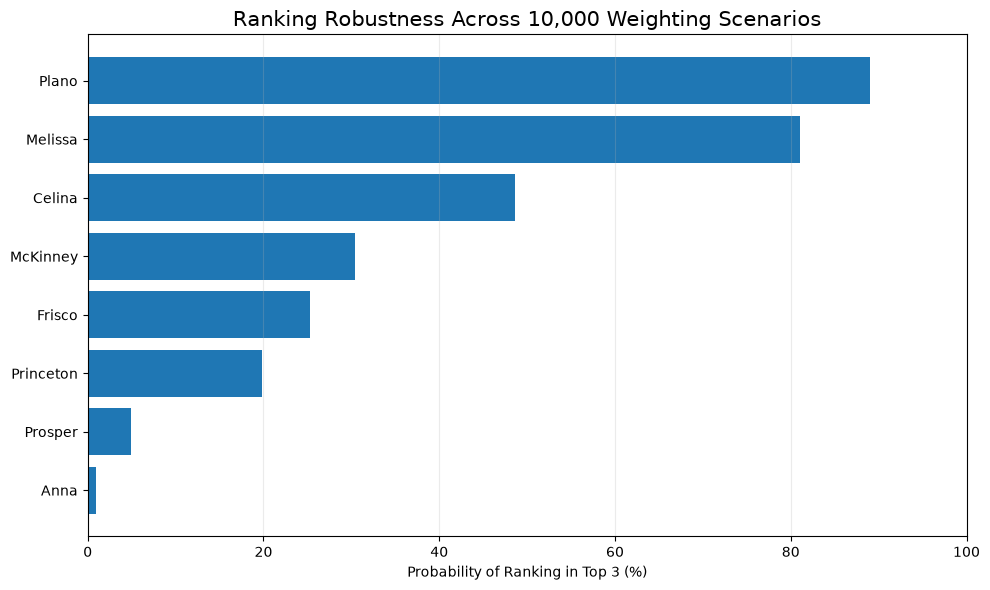

In [39]:
# -------------------------------------------------------------------
# TOP-3 RANKING ROBUSTNESS
# -------------------------------------------------------------------

plot_data = robustness_summary.sort_values(
    "Pct_Top_3"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_data["City"],
    plot_data["Pct_Top_3"]
)

ax.set_title(
    "Ranking Robustness Across 10,000 Weighting Scenarios",
    fontsize=15
)

ax.set_xlabel(
    "Probability of Ranking in Top 3 (%)"
)

ax.set_ylabel("")

ax.set_xlim(0, 100)

ax.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Weight Sensitivity Findings

The Monte Carlo sensitivity analysis demonstrates that market rankings are meaningfully affected by investor priorities, but several conclusions remain relatively robust across alternative weighting specifications.

**Plano** produces the strongest overall ranking robustness. It ranks first in approximately 52% of simulations and appears in the top three in 89% of the 10,000 tested weighting scenarios. Its strong current market conditions compensate for relatively weak demographic growth across a wide range of model specifications.

**Melissa** emerges as the most consistently balanced market. It appears in the top three in approximately 81% of simulations and maintains an average rank of 2.47. Its relatively narrow simulated score distribution also indicates that its attractiveness is less dependent on any single weighting assumption.

**Celina** represents a more investor-dependent opportunity. It ranks first in approximately 23% of simulations but appears in the top three in only 49%. Its exceptional demographic fundamentals can produce very high rankings when long-term growth receives greater emphasis, while weak current market conditions substantially reduce its ranking under other specifications.

**McKinney and Frisco** form a middle tier, with average simulated rankings near 4.5. Neither dominates across weighting specifications, although both become competitive under certain combinations of investor priorities.

**Princeton** exhibits substantial model sensitivity. Its strong population growth and transaction recovery can generate high rankings under some specifications, but weak recent price performance produces a median rank of 7 and the widest simulated score range among the analyzed markets.

**Prosper and Anna** rarely reach the top three under the tested weighting specifications. Anna's relatively narrow score distribution combined with a low average ranking suggests that its weaker position is comparatively robust to alternative model weights.

Overall, the sensitivity analysis supports using the composite scoring framework while emphasizing that the model should not be interpreted as producing a single universally optimal market. Plano and Melissa demonstrate the strongest ranking robustness, while Celina represents the clearest long-term-growth-oriented alternative.

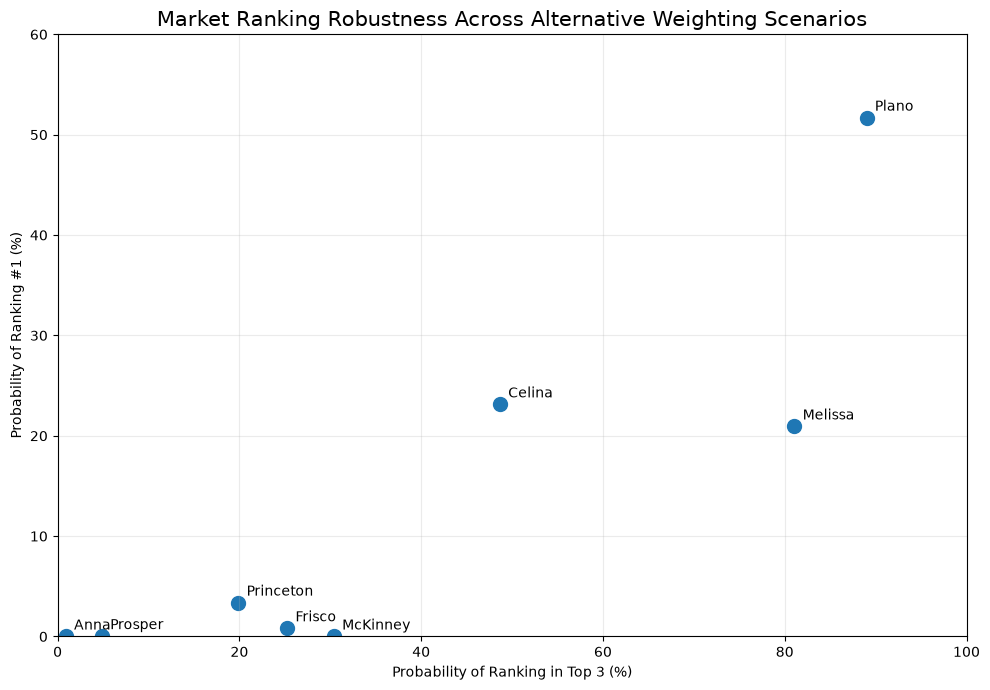

In [40]:
# -------------------------------------------------------------------
# RANKING ROBUSTNESS: #1 VS TOP-3 PROBABILITY
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    robustness_summary["Pct_Top_3"],
    robustness_summary["Pct_Rank_1"],
    s=100
)

for _, row in robustness_summary.iterrows():
    ax.annotate(
        row["City"],
        (
            row["Pct_Top_3"],
            row["Pct_Rank_1"]
        ),
        xytext=(6, 5),
        textcoords="offset points"
    )

ax.set_title(
    "Market Ranking Robustness Across Alternative Weighting Scenarios",
    fontsize=15
)

ax.set_xlabel(
    "Probability of Ranking in Top 3 (%)"
)

ax.set_ylabel(
    "Probability of Ranking #1 (%)"
)

ax.set_xlim(0, 100)
ax.set_ylim(0, 60)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [41]:
# -------------------------------------------------------------------
# CLASSIFY RANKING ROBUSTNESS
# -------------------------------------------------------------------

def classify_robustness(row):

    if row["Pct_Top_3"] >= 75:
        return "Highly Robust"

    elif row["Pct_Top_3"] >= 40:
        return "Moderately Robust"

    elif row["Pct_Top_3"] >= 15:
        return "Weight Sensitive"

    else:
        return "Consistently Lower Ranked"


robustness_summary["Robustness_Profile"] = (
    robustness_summary.apply(
        classify_robustness,
        axis=1
    )
)

robustness_summary[
    [
        "City",
        "Pct_Rank_1",
        "Pct_Top_3",
        "Average_Rank",
        "Score_Range_90Pct",
        "Robustness_Profile"
    ]
].round(2)

,City,Pct_Rank_1,Pct_Top_3,Average_Rank,Score_Range_90Pct,Robustness_Profile
0,Plano,51.70,89.00,1.93,38.80,Highly Robust
1,Melissa,20.93,81.06,2.47,26.93,Highly Robust
2,Celina,23.13,48.66,3.86,35.87,Moderately Robust
3,McKinney,0.00,30.39,4.42,30.95,Weight Sensitive
4,Frisco,0.82,25.25,4.49,35.23,Weight Sensitive
5,Princeton,3.38,19.88,5.95,39.99,Weight Sensitive
6,Prosper,0.04,4.87,6.21,34.24,Consistently Lower Ranked
7,Anna,0.00,0.89,6.67,19.87,Consistently Lower Ranked


## Supply-Demand Balance Analysis

Residential construction is not inherently positive or negative for a housing
market. High permitting activity may reflect strong underlying household growth,
but construction that expands faster than demand can also contribute to rising
inventory, longer marketing times, and weaker pricing.

This section evaluates construction alongside population growth and current
housing-market conditions rather than treating permit activity as a standalone
positive indicator.

In [46]:
# -------------------------------------------------------------------
# BUILD SUPPLY-DEMAND DIAGNOSTIC TABLE
# -------------------------------------------------------------------

supply_demand = market[
    [
        "City",

        # Demographic demand
        "Population_CAGR_Pct",
        "Latest_Population_YoY_Pct",

        # Residential construction
        "Avg_Permits_Per_1000",
        "Latest_Permits_Per_1000",

        # Current supply conditions
        "Inventory_YoY_Pct",
        "Months_of_Supply",
        "Median_DOM",
        "DOM_YoY_Change",

        # Current demand / price signals
        "ZHVI_YoY_Pct",
        "Homes_Sold_YoY_Pct"
    ]
].copy()

print("Shape:", supply_demand.shape)

supply_demand.round(2)

Shape: (8, 11)


,City,Population_CAGR_Pct,Latest_Population_YoY_Pct,Avg_Permits_Per_1000,Latest_Permits_Per_1000,Inventory_YoY_Pct,Months_of_Supply,Median_DOM,DOM_YoY_Change,ZHVI_YoY_Pct,Homes_Sold_YoY_Pct
0,Anna,14.88,10.15,46.91,24.51,10.74,5.90,76.00,14.00,-7.08,4.48
1,Celina,29.00,24.58,89.64,43.51,15.93,6.80,83.00,10.00,-9.34,34.45
2,Frisco,3.17,0.76,14.90,23.85,4.70,4.90,50.00,2.00,-4.56,6.57
3,McKinney,3.63,3.74,14.72,12.88,-10.07,4.10,45.00,0.00,-6.11,-5.24
4,Melissa,15.89,14.48,47.25,18.45,-13.59,5.20,60.00,3.00,-6.02,-4.55
5,Plano,0.46,-0.13,2.88,1.07,-19.70,3.40,36.00,1.00,-4.43,4.27
6,Princeton,19.99,18.09,61.87,36.99,-1.06,3.30,61.00,-5.00,-10.23,40.06
7,Prosper,8.15,2.46,24.66,5.72,0.24,5.30,66.00,0.00,-5.71,-6.18


In [47]:
# -------------------------------------------------------------------
# VALIDATE SUPPLY-DEMAND DATA
# -------------------------------------------------------------------

print("Cities:", supply_demand["City"].nunique())
print("Rows:", len(supply_demand))
print(
    "Missing values:",
    supply_demand.isna().sum().sum()
)

supply_demand

Cities: 8
Rows: 8
Missing values: 0


,City,Population_CAGR_Pct,Latest_Population_YoY_Pct,Avg_Permits_Per_1000,Latest_Permits_Per_1000,Inventory_YoY_Pct,Months_of_Supply,Median_DOM,DOM_YoY_Change,ZHVI_YoY_Pct,Homes_Sold_YoY_Pct
0,Anna,14.88,10.15,46.91,24.51,10.74,5.90,76.00,14.00,-7.08,4.48
1,Celina,29.00,24.58,89.64,43.51,15.93,6.80,83.00,10.00,-9.34,34.45
2,Frisco,3.17,0.76,14.90,23.85,4.70,4.90,50.00,2.00,-4.56,6.57
3,McKinney,3.63,3.74,14.72,12.88,-10.07,4.10,45.00,0.00,-6.11,-5.24
4,Melissa,15.89,14.48,47.25,18.45,-13.59,5.20,60.00,3.00,-6.02,-4.55
5,Plano,0.46,-0.13,2.88,1.07,-19.70,3.40,36.00,1.00,-4.43,4.27
6,Princeton,19.99,18.09,61.87,36.99,-1.06,3.30,61.00,-5.00,-10.23,40.06
7,Prosper,8.15,2.46,24.66,5.72,0.24,5.30,66.00,0.00,-5.71,-6.18


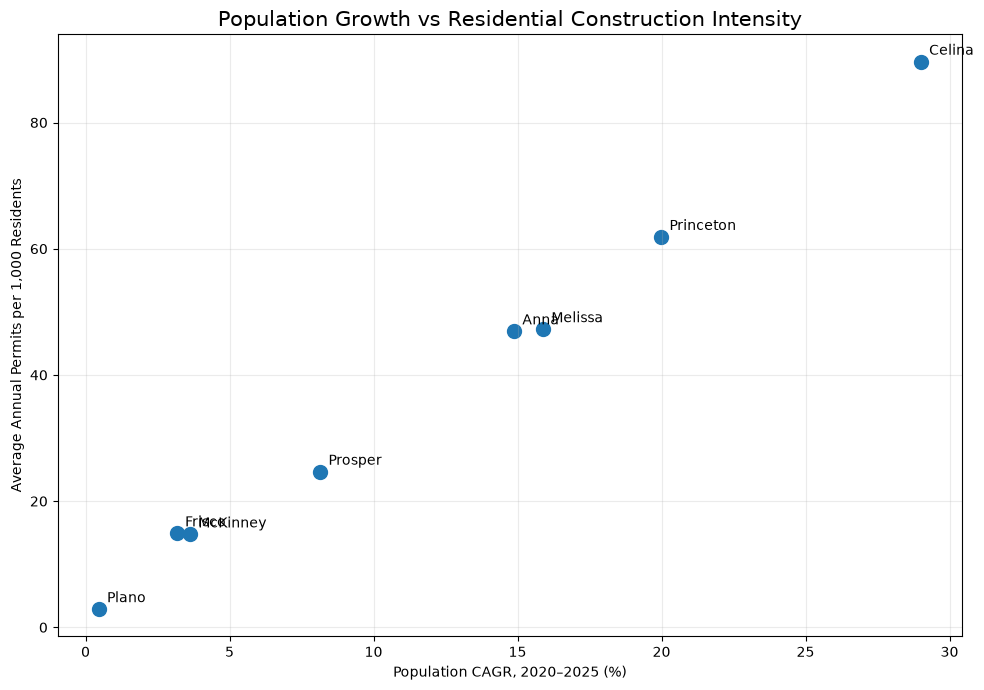

In [48]:
# -------------------------------------------------------------------
# POPULATION GROWTH VS CONSTRUCTION INTENSITY
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    supply_demand["Population_CAGR_Pct"],
    supply_demand["Avg_Permits_Per_1000"],
    s=100
)

for _, row in supply_demand.iterrows():
    ax.annotate(
        row["City"],
        (
            row["Population_CAGR_Pct"],
            row["Avg_Permits_Per_1000"]
        ),
        xytext=(6, 5),
        textcoords="offset points"
    )

ax.set_title(
    "Population Growth vs Residential Construction Intensity",
    fontsize=15
)

ax.set_xlabel(
    "Population CAGR, 2020–2025 (%)"
)

ax.set_ylabel(
    "Average Annual Permits per 1,000 Residents"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [49]:
# -------------------------------------------------------------------
# EXPECTED CONSTRUCTION GIVEN POPULATION GROWTH
# -------------------------------------------------------------------

import numpy as np

x = supply_demand["Population_CAGR_Pct"].values
y = supply_demand["Avg_Permits_Per_1000"].values

slope, intercept = np.polyfit(x, y, 1)

supply_demand["Expected_Permits_Per_1000"] = (
    intercept
    + slope * supply_demand["Population_CAGR_Pct"]
)

supply_demand["Construction_Gap"] = (
    supply_demand["Avg_Permits_Per_1000"]
    - supply_demand["Expected_Permits_Per_1000"]
)

print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")

supply_demand[
    [
        "City",
        "Population_CAGR_Pct",
        "Avg_Permits_Per_1000",
        "Expected_Permits_Per_1000",
        "Construction_Gap"
    ]
].sort_values(
    "Construction_Gap",
    ascending=False
).round(2)

Slope: 2.95
Intercept: 2.73


,City,Population_CAGR_Pct,Avg_Permits_Per_1000,Expected_Permits_Per_1000,Construction_Gap
2,Frisco,3.17,14.90,12.08,2.81
3,McKinney,3.63,14.72,13.44,1.29
1,Celina,29.00,89.64,88.38,1.26
0,Anna,14.88,46.91,46.67,0.24
6,Princeton,19.99,61.87,61.76,0.12
5,Plano,0.46,2.88,4.08,-1.20
7,Prosper,8.15,24.66,26.79,-2.12
4,Melissa,15.89,47.25,49.65,-2.40


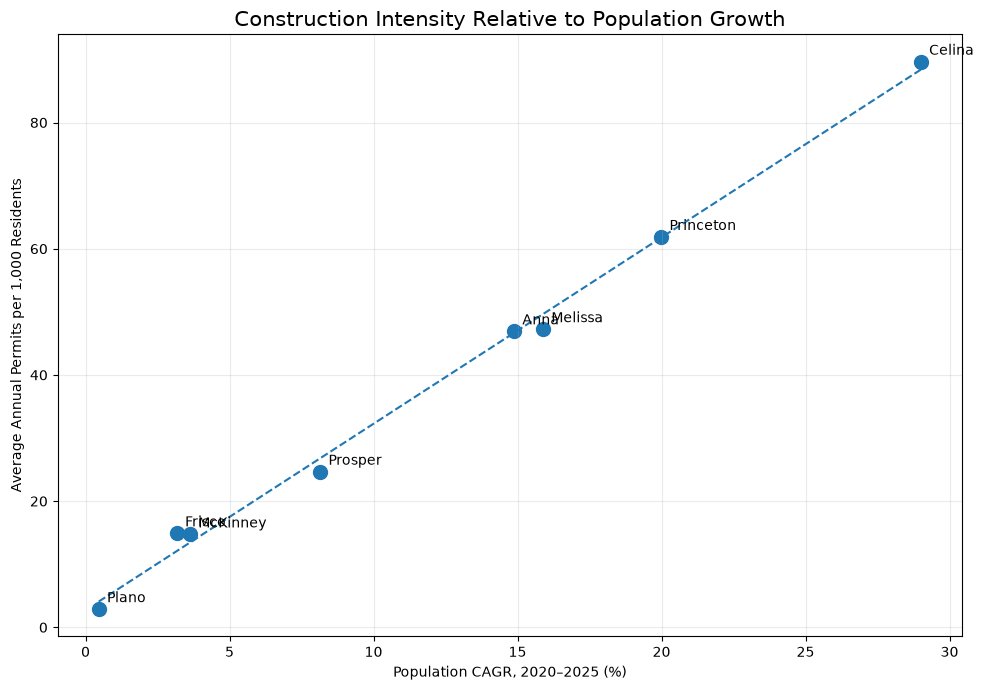

In [50]:
# -------------------------------------------------------------------
# CONSTRUCTION RELATIVE TO DEMOGRAPHIC GROWTH
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    supply_demand["Population_CAGR_Pct"],
    supply_demand["Avg_Permits_Per_1000"],
    s=100
)

x_line = np.linspace(
    supply_demand["Population_CAGR_Pct"].min(),
    supply_demand["Population_CAGR_Pct"].max(),
    100
)

y_line = intercept + slope * x_line

ax.plot(
    x_line,
    y_line,
    linestyle="--"
)

for _, row in supply_demand.iterrows():
    ax.annotate(
        row["City"],
        (
            row["Population_CAGR_Pct"],
            row["Avg_Permits_Per_1000"]
        ),
        xytext=(6, 5),
        textcoords="offset points"
    )

ax.set_title(
    "Construction Intensity Relative to Population Growth",
    fontsize=15
)

ax.set_xlabel(
    "Population CAGR, 2020–2025 (%)"
)

ax.set_ylabel(
    "Average Annual Permits per 1,000 Residents"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

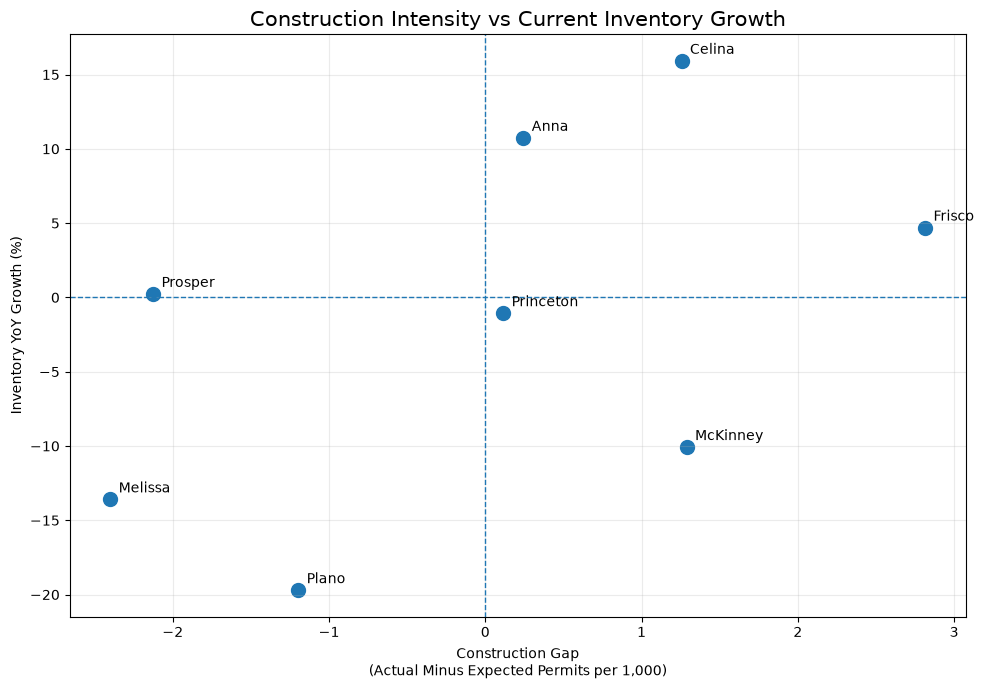

In [51]:
# -------------------------------------------------------------------
# CONSTRUCTION GAP VS CURRENT INVENTORY CONDITIONS
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    supply_demand["Construction_Gap"],
    supply_demand["Inventory_YoY_Pct"],
    s=100
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

for _, row in supply_demand.iterrows():
    ax.annotate(
        row["City"],
        (
            row["Construction_Gap"],
            row["Inventory_YoY_Pct"]
        ),
        xytext=(6, 5),
        textcoords="offset points"
    )

ax.set_title(
    "Construction Intensity vs Current Inventory Growth",
    fontsize=15
)

ax.set_xlabel(
    "Construction Gap\n"
    "(Actual Minus Expected Permits per 1,000)"
)

ax.set_ylabel(
    "Inventory YoY Growth (%)"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Market Diagnosis Layer

The composite ranking model measures long-term fundamentals and current market
momentum, but markets with similar scores can have very different underlying
conditions.

This section combines demographic growth, construction activity, transaction
activity, inventory, supply, and price trends to identify the economic profile
of each market.

These classifications are diagnostic rather than additional components of the
composite ranking score.

In [53]:
# ------------------------------------------------------------
# BUILD MARKET DIAGNOSTIC DATASET
# ------------------------------------------------------------

market_diagnosis = model_data[
    [
        "City",
        "Population_CAGR_Pct",
        "Five_Year_CAGR_Pct",
        "Population_Growth_Acceleration",
        "ZHVI_YoY_Pct",
        "Homes_Sold_YoY_Pct",
        "Inventory_YoY_Pct",
        "Months_of_Supply",
        "Sale_to_List_Pct",
        "Avg_Permits_Per_1000",
        "Latest_Permits_Per_1000",
        "Change_From_Construction_Peak_Pct",
    ]
].copy()

# Add the construction-gap diagnostic previously calculated
market_diagnosis = market_diagnosis.merge(
    supply_demand[
        [
            "City",
            "Expected_Permits_Per_1000",
            "Construction_Gap",
        ]
    ],
    on="City",
    how="left",
)

market_diagnosis.round(2)

,City,Population_CAGR_Pct,Five_Year_CAGR_Pct,Population_Growth_Acceleration,ZHVI_YoY_Pct,Homes_Sold_YoY_Pct,Inventory_YoY_Pct,Months_of_Supply,Sale_to_List_Pct,Avg_Permits_Per_1000,Latest_Permits_Per_1000,Change_From_Construction_Peak_Pct,Expected_Permits_Per_1000,Construction_Gap
0,Anna,14.88,1.01,-4.37,-7.08,4.48,10.74,5.90,97.73,46.91,24.51,-59.61,46.67,0.24
1,Celina,29.00,2.85,6.55,-9.34,34.45,15.93,6.80,96.50,89.64,43.51,-69.60,88.38,1.26
2,Frisco,3.17,3.81,-2.89,-4.56,6.57,4.70,4.90,97.29,14.90,23.85,0.00,12.08,2.81
3,McKinney,3.63,2.67,-1.67,-6.11,-5.24,-10.07,4.10,97.76,14.72,12.88,-42.10,13.44,1.29
4,Melissa,15.89,2.10,4.49,-6.02,-4.55,-13.59,5.20,97.90,47.25,18.45,-75.69,49.65,-2.40
5,Plano,0.46,3.23,-0.13,-4.43,4.27,-19.70,3.40,97.90,2.88,1.07,-82.50,4.08,-1.20
6,Princeton,19.99,-0.35,-12.45,-10.23,40.06,-1.06,3.30,97.33,61.87,36.99,-63.76,61.76,0.12
7,Prosper,8.15,3.96,-3.45,-5.71,-6.18,0.24,5.30,96.36,24.66,5.72,-85.29,26.79,-2.12


In [61]:
# ------------------------------------------------------------
# ADD FORWARD-LOOKING / LIQUIDITY DIAGNOSTICS
# ------------------------------------------------------------

market_diagnosis = market_diagnosis.merge(
    market[
        [
            "City",
            "Pending_Sales_YoY_Pct",
            "DOM_YoY_Change",
            "New_Listings_YoY_Pct",
        ]
    ],
    on="City",
    how="left",
    validate="one_to_one"
)

print("Rows:", len(market_diagnosis))
print("Unique cities:", market_diagnosis["City"].nunique())
print("Missing values:", market_diagnosis.isna().sum().sum())

market_diagnosis.round(2)

Rows: 8
Unique cities: 8
Missing values: 0


,City,Population_CAGR_Pct,Five_Year_CAGR_Pct,Population_Growth_Acceleration,ZHVI_YoY_Pct,Homes_Sold_YoY_Pct,Inventory_YoY_Pct,Months_of_Supply,Sale_to_List_Pct,Avg_Permits_Per_1000,Latest_Permits_Per_1000,Change_From_Construction_Peak_Pct,Expected_Permits_Per_1000,Construction_Gap,Pending_Sales_YoY_Pct_x,DOM_YoY_Change_x,New_Listings_YoY_Pct_x,Pending_Sales_YoY_Pct_y,DOM_YoY_Change_y,New_Listings_YoY_Pct_y,Pending_Sales_YoY_Pct,DOM_YoY_Change,New_Listings_YoY_Pct
0,Anna,14.88,1.01,-4.37,-7.08,4.48,10.74,5.90,97.73,46.91,24.51,-59.61,46.67,0.24,5.88,14.00,-1.88,5.88,14.00,-1.88,5.88,14.00,-1.88
1,Celina,29.00,2.85,6.55,-9.34,34.45,15.93,6.80,96.50,89.64,43.51,-69.60,88.38,1.26,44.17,10.00,23.48,44.17,10.00,23.48,44.17,10.00,23.48
2,Frisco,3.17,3.81,-2.89,-4.56,6.57,4.70,4.90,97.29,14.90,23.85,0.00,12.08,2.81,-1.81,2.00,-0.18,-1.81,2.00,-0.18,-1.81,2.00,-0.18
3,McKinney,3.63,2.67,-1.67,-6.11,-5.24,-10.07,4.10,97.76,14.72,12.88,-42.10,13.44,1.29,-12.53,0.00,-14.55,-12.53,0.00,-14.55,-12.53,0.00,-14.55
4,Melissa,15.89,2.10,4.49,-6.02,-4.55,-13.59,5.20,97.90,47.25,18.45,-75.69,49.65,-2.40,-16.67,3.00,-12.64,-16.67,3.00,-12.64,-16.67,3.00,-12.64
5,Plano,0.46,3.23,-0.13,-4.43,4.27,-19.70,3.40,97.90,2.88,1.07,-82.50,4.08,-1.20,-6.38,1.00,-17.03,-6.38,1.00,-17.03,-6.38,1.00,-17.03
6,Princeton,19.99,-0.35,-12.45,-10.23,40.06,-1.06,3.30,97.33,61.87,36.99,-63.76,61.76,0.12,39.94,-5.00,-15.67,39.94,-5.00,-15.67,39.94,-5.00,-15.67
7,Prosper,8.15,3.96,-3.45,-5.71,-6.18,0.24,5.30,96.36,24.66,5.72,-85.29,26.79,-2.12,-11.60,0.00,-18.94,-11.60,0.00,-18.94,-11.60,0.00,-18.94


In [64]:
# ------------------------------------------------------------
# CREATE MARKET DIAGNOSTIC SIGNALS
# ------------------------------------------------------------

market_diagnosis["Demand_Recovery_Signal"] = (
    (market_diagnosis["Homes_Sold_YoY_Pct"] > 0) 
    & (market_diagnosis["Pending_Sales_YoY_Pct"] > 0)
)

market_diagnosis["Supply_Expansion_Signal"] = (
    (market_diagnosis["Inventory_YoY_Pct"] > 5) & (market_diagnosis["Months_of_Supply"] > 5.5)
)

market_diagnosis["Market_Speed_Improving"] = (
    market_diagnosis["DOM_YoY_Change"] < 0
)

market_diagnosis["Price_Correction"] = (
    market_diagnosis["ZHVI_YoY_Pct"]< -5
)

market_diagnosis["Strong_Demographic_Growth"] = (
    market_diagnosis["Population_CAGR_Pct"] >= 8
)

signal_cols = [
    "City",
    "Demand_Recovery_Signal",
    "Supply_Expansion_Signal",
    "Market_Speed_Improving",
    "Price_Correction",
    "Strong_Demographic_Growth"
]

market_diagnosis[signal_cols]

,City,Demand_Recovery_Signal,Supply_Expansion_Signal,Market_Speed_Improving,Price_Correction,Strong_Demographic_Growth
0,Anna,True,True,False,True,True
1,Celina,True,True,False,True,True
2,Frisco,False,False,False,False,False
3,McKinney,False,False,False,True,False
4,Melissa,False,False,False,True,True
5,Plano,False,False,False,False,False
6,Princeton,True,False,True,True,True
7,Prosper,False,False,False,True,True


In [65]:
signal_display = market_diagnosis[signal_cols].copy()

for col in signal_cols[1:]:
    signal_display[col] = signal_display[col].map(
        {True: "Yes", False: "No"}
    )

signal_display

,City,Demand_Recovery_Signal,Supply_Expansion_Signal,Market_Speed_Improving,Price_Correction,Strong_Demographic_Growth
0,Anna,Yes,Yes,No,Yes,Yes
1,Celina,Yes,Yes,No,Yes,Yes
2,Frisco,No,No,No,No,No
3,McKinney,No,No,No,Yes,No
4,Melissa,No,No,No,Yes,Yes
5,Plano,No,No,No,No,No
6,Princeton,Yes,No,Yes,Yes,Yes
7,Prosper,No,No,No,Yes,Yes


In [68]:
# ------------------------------------------------------------
# CLASSIFY CURRENT MARKET REGIME
# ------------------------------------------------------------

def classify_market_regime(row):

    demand = row["Demand_Recovery_Signal"]
    supply = row["Supply_Expansion_Signal"]
    correction = row["Price_Correction"]

    if demand and not supply and correction:
        return "Recovery + Repricing"
    
    elif demand and supply:
        return "Demand Growth + Supply Pressure"

    elif not demand and supply:
        return "Supply-Heaving + Cooling"

    elif not correction and not supply:
        return "Relatively Stable"

    else:
        return "Mixed + Transitional"

market_diagnosis["Current_Market_Regime"] = (
    market_diagnosis.apply(
        classify_market_regime,
        axis=1
    )
)

regime_summary = market_diagnosis[
    [
        "City",
        "ZHVI_YoY_Pct",
        "Homes_Sold_YoY_Pct",
        "Pending_Sales_YoY_Pct",
        "Inventory_YoY_Pct",
        "Months_of_Supply",
        "DOM_YoY_Change",
        "Current_Market_Regime"
    ]
].sort_values(
    [
        "Current_Market_Regime",
        "City"
    ]
    
)

regime_summary.round(2)

,City,ZHVI_YoY_Pct,Homes_Sold_YoY_Pct,Pending_Sales_YoY_Pct,Inventory_YoY_Pct,Months_of_Supply,DOM_YoY_Change,Current_Market_Regime
0,Anna,-7.08,4.48,5.88,10.74,5.90,14.00,Demand Growth + Supply Pressure
1,Celina,-9.34,34.45,44.17,15.93,6.80,10.00,Demand Growth + Supply Pressure
3,McKinney,-6.11,-5.24,-12.53,-10.07,4.10,0.00,Mixed + Transitional
4,Melissa,-6.02,-4.55,-16.67,-13.59,5.20,3.00,Mixed + Transitional
7,Prosper,-5.71,-6.18,-11.60,0.24,5.30,0.00,Mixed + Transitional
6,Princeton,-10.23,40.06,39.94,-1.06,3.30,-5.00,Recovery + Repricing
2,Frisco,-4.56,6.57,-1.81,4.70,4.90,2.00,Relatively Stable
5,Plano,-4.43,4.27,-6.38,-19.70,3.40,1.00,Relatively Stable


# Integrated Investment Interpretation

The compositive scoring model identifies markets that perform well under different investor priorities, while the robustness analysis measures how sensitive these rankings are to alternative weighing assumptions.

The market-regime framework adds an economic interpretation layer by identifying whether current conditions reflect relative stability, recovery, supply pressure, or mixed market signals.

Together, these measures distinguish between a high ranking caused by current market resilience and a high ranking driven primarily by long-term growth potential.

In [82]:
# ------------------------------------------------------------
# BUILD INTEGRATED INVESTMENT SUMMARY
# ------------------------------------------------------------

investment_summary = scores[
    [
        "City",
        "Long_Term_Fundamentals_Score",
        "Fundamentals_Rank",
        "Current_Market_Momentum_Score",
        "Momentum_Rank",
        "Market_Profile",
    ]
].copy()

# Add Monte Carlo robustness results
investment_summary = investment_summary.merge(
    robustness_summary[
        [
            "City",
            "Pct_Rank_1",
            "Pct_Top_3",
            "Average_Rank",
            "Median_Rank",
            "Mean_Score",
            "Score_Range_90Pct",
            "Robustness_Profile",
        ]
    ],
    on="City",
    how="left",
    validate="one_to_one",
)

# Add current economic regime
investment_summary = investment_summary.merge(
    market_diagnosis[
        [
            "City",
            "Current_Market_Regime",
        ]
    ],
    on="City",
    how="left",
    validate="one_to_one",
)

investment_summary = (
    investment_summary
    .sort_values(
        ["Average_Rank", "Pct_Top_3"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

print("Shape:", investment_summary.shape)
print("Missing values:", investment_summary.isna().sum().sum())

investment_summary.round(2)

Shape: (8, 14)
Missing values: 0


,City,Long_Term_Fundamentals_Score,Fundamentals_Rank,Current_Market_Momentum_Score,Momentum_Rank,Market_Profile,Pct_Rank_1,Pct_Top_3,Average_Rank,Median_Rank,Mean_Score,Score_Range_90Pct,Robustness_Profile,Current_Market_Regime
0,Plano,42.03,6,83.95,1,Weaker Fundamentals + Strong Momentum,51.70,89.00,1.93,1.00,66.56,38.80,Highly Robust,Relatively Stable
1,Melissa,62.08,2,59.54,3,Strong Fundamentals + Strong Momentum,20.93,81.06,2.47,2.00,63.76,26.93,Highly Robust,Mixed + Transitional
2,Celina,91.02,1,22.77,8,Strong Fundamentals + Weak Momentum,23.13,48.66,3.86,4.00,56.84,35.87,Moderately Robust,Demand Growth + Supply Pressure
3,McKinney,40.91,7,61.79,2,Weaker Fundamentals + Strong Momentum,0.00,30.39,4.42,4.00,54.37,30.95,Weight Sensitive,Mixed + Transitional
4,Frisco,48.11,4,56.16,5,Weaker Fundamentals + Strong Momentum,0.82,25.25,4.49,4.00,53.15,35.23,Weight Sensitive,Relatively Stable
5,Princeton,30.79,8,58.98,4,Weaker Fundamentals + Strong Momentum,3.38,19.88,5.95,7.00,42.67,39.99,Weight Sensitive,Recovery + Repricing
6,Prosper,56.59,3,36.87,7,Strong Fundamentals + Weak Momentum,0.04,4.87,6.21,6.00,45.45,34.24,Consistently Lower Ranked,Mixed + Transitional
7,Anna,42.30,5,39.57,6,Weaker Fundamentals + Weak Momentum,0.00,0.89,6.67,7.00,41.49,19.87,Consistently Lower Ranked,Demand Growth + Supply Pressure


In [83]:
# ------------------------------------------------------------
# VALIDATE INTEGRATED INVESTMENT SUMMARY
# ------------------------------------------------------------

print("INTEGRATED INVESTMENT SUMMARY VALIDATION")
print("-" * 50)

print("Rows:", len(investment_summary))
print("Unique cities:", investment_summary["City"].nunique())
print("Duplicate cities:", investment_summary["City"].duplicated().sum())
print("Missing values:", investment_summary.isna().sum().sum())

INTEGRATED INVESTMENT SUMMARY VALIDATION
--------------------------------------------------
Rows: 8
Unique cities: 8
Duplicate cities: 0
Missing values: 0


In [85]:
# ------------------------------------------------------------
# FINAL DECISION TABLE
# ------------------------------------------------------------

decision_table = investment_summary[
    [
        "City",
        "Long_Term_Fundamentals_Score",
        "Fundamentals_Rank",
        "Current_Market_Momentum_Score",
        "Momentum_Rank",
        "Pct_Rank_1",
        "Pct_Top_3",
        "Average_Rank",
        "Robustness_Profile",
        "Current_Market_Regime",
    ]
].copy()

decision_table = (
    decision_table
    .sort_values(
        ["Average_Rank", "Pct_Top_3"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

decision_table.round(2)

,City,Long_Term_Fundamentals_Score,Fundamentals_Rank,Current_Market_Momentum_Score,Momentum_Rank,Pct_Rank_1,Pct_Top_3,Average_Rank,Robustness_Profile,Current_Market_Regime
0,Plano,42.03,6,83.95,1,51.70,89.00,1.93,Highly Robust,Relatively Stable
1,Melissa,62.08,2,59.54,3,20.93,81.06,2.47,Highly Robust,Mixed + Transitional
2,Celina,91.02,1,22.77,8,23.13,48.66,3.86,Moderately Robust,Demand Growth + Supply Pressure
3,McKinney,40.91,7,61.79,2,0.00,30.39,4.42,Weight Sensitive,Mixed + Transitional
4,Frisco,48.11,4,56.16,5,0.82,25.25,4.49,Weight Sensitive,Relatively Stable
5,Princeton,30.79,8,58.98,4,3.38,19.88,5.95,Weight Sensitive,Recovery + Repricing
6,Prosper,56.59,3,36.87,7,0.04,4.87,6.21,Consistently Lower Ranked,Mixed + Transitional
7,Anna,42.30,5,39.57,6,0.00,0.89,6.67,Consistently Lower Ranked,Demand Growth + Supply Pressure


## Final Market Ranking Interpretation

The analysis does not identify a single market that dominates across every
investment objective. Instead, the results reveal distinct investment profiles.

**Plano** is the most robust market across alternative weighting assumptions.
Although its long-term demographic growth is relatively modest, it currently
has the strongest market-momentum score and ranks in the top three in 89% of
simulated weighting scenarios.

**Melissa** provides the strongest balance between long-term fundamentals and
current market conditions. It ranks second in long-term fundamentals and third
in current momentum, resulting in an 81.06% probability of ranking in the top
three across alternative investor priorities.

**Celina** represents the strongest long-term growth opportunity but also the
largest disconnect between fundamentals and current conditions. It ranks first
in long-term fundamentals but eighth in current momentum. Rapid population
growth and residential construction support the long-run investment thesis,
while rising inventory, elevated supply, and weaker price performance create
near-term pressure.

**McKinney and Frisco** occupy the middle of the rankings and are more sensitive
to investor weighting assumptions. McKinney benefits from relatively strong
current conditions, while Frisco combines moderate fundamentals with a
comparatively stable current market.

**Princeton** exhibits characteristics of a recovery and repricing market.
Transaction and pending-sales growth have strengthened despite substantial
home-value declines, suggesting improving demand at lower price levels.
However, its weaker long-term composite score makes the investment case more
dependent on a successful recovery.

**Prosper and Anna** rank less favorably across most weighting scenarios.
Prosper retains relatively strong long-term fundamentals but currently exhibits
weaker market momentum, while Anna faces both weaker composite rankings and
current supply pressure.

Overall, the model distinguishes between three particularly important
investment profiles:

- **Most robust current opportunity:** Plano
- **Best balance of fundamentals and momentum:** Melissa
- **Strongest long-term growth thesis:** Celina

These rankings should be interpreted as comparative market signals rather than
guaranteed investment outcomes. The analysis evaluates city-level market
conditions and does not incorporate property-specific acquisition price,
financing, rental income, operating expenses, or individual property quality.

In [86]:
# ------------------------------------------------------------
# EXPORT NOTEBOOK 03 MODEL OUTPUTS
# ------------------------------------------------------------

OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

scores.to_csv(
    OUTPUT_DIR / "tx_market_scores.csv",
    index=False
)

robustness_summary.to_csv(
    OUTPUT_DIR / "tx_ranking_robustness.csv",
    index=False
)

market_diagnosis.to_csv(
    OUTPUT_DIR / "tx_market_diagnostics.csv",
    index=False
)

decision_table.to_csv(
    OUTPUT_DIR / "tx_final_decision_table.csv",
    index=False
)

print("Exports complete:")
print("- tx_market_scores.csv")
print("- tx_ranking_robustness.csv")
print("- tx_market_diagnostics.csv")
print("- tx_final_decision_table.csv")

Exports complete:
- tx_market_scores.csv
- tx_ranking_robustness.csv
- tx_market_diagnostics.csv
- tx_final_decision_table.csv


In [88]:
# ------------------------------------------------------------
# FINAL NOTEBOOK VALIDATION
# ------------------------------------------------------------

for filename in [
    "tx_market_scores.csv",
    "tx_ranking_robustness.csv",
    "tx_market_diagnostics.csv",
    "tx_final_decision_table.csv",
]:
    path = OUTPUT_DIR / filename

    print(
        f"{filename:<45}"
        f"Exists: {path.exists()}"
    )

tx_market_scores.csv                         Exists: True
tx_ranking_robustness.csv                    Exists: True
tx_market_diagnostics.csv                    Exists: True
tx_final_decision_table.csv                  Exists: True
